# Tardis Project

We, Loup, Lukas, and Eva, are part of a newly formed **SNCF Data Analysis Service**, dedicated to improving the efficiency of train travel across the country.

Our mission? Analyze historical train delay data, uncover hidden patterns, and develop a predictive model that can forecast delays before they happen. The SNCF has entrusted our team with making the railway system more efficient and transparent.

If we <span style="color:green">succeed</span>, our dashboard will be used by thousands of travelers to better plan their journeys. If we <span style="color:red">fail</span>... well, we expect a lot more unhappy commuters. 

No pressure! Using the provided dataset, our job is to clean and analyze historical delay data, develop a simple predictive model, and present our insights through an interactive **Streamlit dashboard**.

In [1]:
# Importing the libraries to manage the dataset and visualize data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# --- CLEANING UTILITY FUNCTIONS ---

def clean_numeric_column(df, column_name, text_to_remove=None, to_type='float'):
    """
    Cleans a column surgically without using 'coerce'.
    Extracts the first valid numeric sequence found in the cell.
    """
    if column_name not in df.columns:
        return df
    
    # 1. Prepare work buffer as string
    processed_col = df[column_name].astype(str)
    
    # 2. Remove specific text if provided ("min")
    if text_to_remove is not None:
        processed_col = processed_col.str.replace(text_to_remove, "", regex=False)
    
    # 3. Normalization (commas -> dots, strip spaces)
    processed_col = processed_col.str.replace(",", ".", regex=False).str.strip()
    
    # 4. SECURITY FILTER: Extract the first valid number
    # Pattern: [optional sign] [digits] [optional dot] [digits]
    processed_col = processed_col.str.extract(r'([-+]?\d*\.?\d+)')[0]
    
    # 5. Final conversion (errors='raise' to guarantee cleaning quality and catch errors)
    df[column_name] = pd.to_numeric(processed_col, errors='raise')
    
    # 6. Final typing
    if to_type == 'int':
        df[column_name] = df[column_name].round().astype('Int64')
    else:
        df[column_name] = df[column_name].astype(float)
        
    return df

def drop_invalid_rows(df, column_name):
    """ Removes rows where the value is null or unusable. """
    return df.dropna(subset=[column_name])

def impute_missing_with_value(df, column_name, value):
    """ Replaces missing values with a fixed value (0). """
    df[column_name] = df[column_name].fillna(value)
    return df

def impute_missing_with_mean(df, column_name):
    """ Replaces missing values with the column mean. """
    mean_val = df[column_name].mean()
    df[column_name] = df[column_name].fillna(mean_val)
    return df

# Step 1: Data Exploration and Cleaning
## 1. Loading the Dataset

Examining column names, count, and data types.

In [3]:
df = pd.read_csv("dataset.csv", sep=";")
print("Column names and types:")

# Displaying column types
for col in df.columns:
    print(f"{col} -> {df[col].dtype}")

Column names and types:
Date -> str
Service -> str
Departure station -> str
Arrival station -> str
Average journey time -> str
Number of scheduled trains -> str
Number of cancelled trains -> str
Cancellation comments -> str
Number of trains delayed at departure -> str
Average delay of late trains at departure -> str
Average delay of all trains at departure -> str
Departure delay comments -> str
Number of trains delayed at arrival -> str
Average delay of late trains at arrival -> str
Average delay of all trains at arrival -> str
Arrival delay comments -> str
Number of trains delayed > 15min -> str
Average delay of trains > 15min (if competing with flights) -> str
Number of trains delayed > 30min -> str
Number of trains delayed > 60min -> str
Pct delay due to external causes -> str
Pct delay due to infrastructure -> str
Pct delay due to traffic management -> str
Pct delay due to rolling stock -> str
Pct delay due to station management and equipment reuse -> str
Pct delay due to passenger

### Initial Data Inspection
We examine raw dataset statistics and preview the data.

In [4]:
display(df.describe())

print("\nInitial dataset preview:")
display(df.head())

nb_line_start, nb_col_start = df.shape
print(f"\nThe original dataset contains {nb_col_start} columns and {nb_line_start} rows.")

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
count,12010,11830,12011,12011,11830,11830,11831,577,11830,11831,...,11828,11831,11832,11833,11828,11827,11829,11827,11828,11830
unique,318,2,132,116,651,1034,248,3,629,11162,...,265,11075,175,96,2732,2592,2677,2535,2130,2172
top,2025-09,National,PARIS LYON,PARIS LYON,96.0,31.0,0.0,Non communiqué,13.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
freq,135,10370,2405,2413,184,117,3917,196,161,134,...,327,218,779,1760,1100,1021,1326,1220,3361,3809



Initial dataset preview:


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965



The original dataset contains 26 columns and 12070 rows.


### Visualizing Missing Values
Before cleaning, we identify missing values in the raw data using a heatmap.

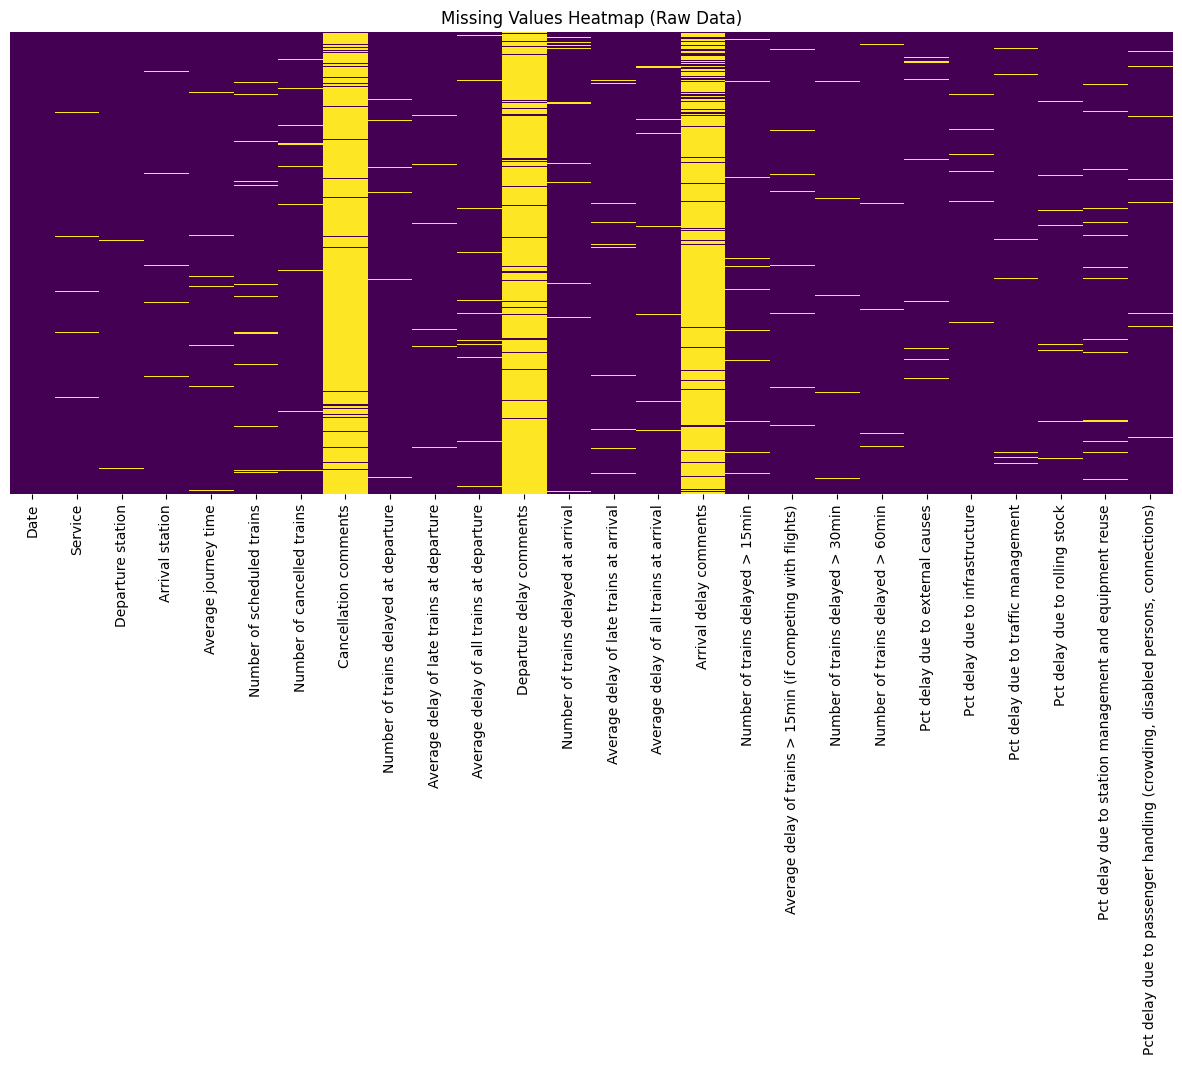

In [5]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Raw Data)')
plt.show()

## 2. Duplicate Removal
We remove identical rows to ensure data integrity.

In [6]:
df = df.drop_duplicates()

nb_line_after_dupes, _ = df.shape
print(f"Rows after duplicate removal: {nb_line_after_dupes} ({nb_line_start - nb_line_after_dupes} rows removed).")

Rows after duplicate removal: 11896 (174 rows removed).


## 3. Data Cleaning and Column Formatting

### Date Column
We standardize the `Date` column and extract `Year` and `Month` features.

In [7]:
# Convert to datetime and standardize format
df['Date'] = pd.to_datetime(df['Date'], yearfirst=True, format='mixed')

# Drop rows with missing dates (critical for analysis)
df = drop_invalid_rows(df, 'Date')

# Extract Year and Month, then drop the original Date column
df['Year'] = df['Date'].dt.year.astype(int)
df['Month'] = df['Date'].dt.month.astype(int)
df = df.drop(columns=['Date'])

# Place the Year and Month columns at the bdeginning of the DataFrame
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
df = df[['Year', 'Month'] + cols]

print(f"Remaining rows after date validation: {len(df)}")
display(df[['Year', 'Month']].head())

Remaining rows after date validation: 11837


,Year,Month
0,2018,1
1,2018,1
2,2018,1
3,2018,1
4,2018,1


### Season Feature
We create a `Season` column based on the month.

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

#Place the Season column after Month
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
cols.remove('Season')
df = df[['Year', 'Month', 'Season'] + cols]

display(df[['Month', 'Season']].head())

,Month,Month,Season
0,1,1,Winter
1,1,1,Winter
2,1,1,Winter
3,1,1,Winter
4,1,1,Winter


### Service Column
We ensure the `Service` column only contains 'National' or 'International' values. Other values are set to `NaN`.

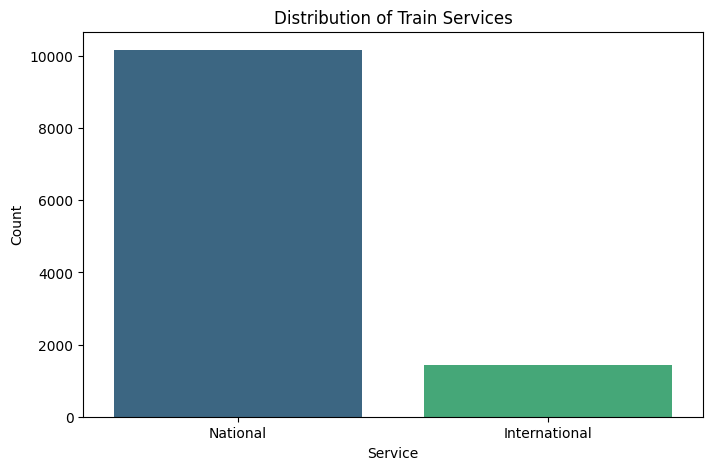

Rows with missing or invalid Service values: 235
Service counts:


In [9]:
# List of valid service categories for the SNCF network
valid_services = ['national', 'international']

# 1. Convert to lowercase and strip whitespace for uniform comparison
df['Service'] = df['Service'].str.lower().str.strip()

# 2. Apply a transformation to each cell using a 'lambda' function:
# - If the value is valid, capitalize it ('national' -> 'National')
# - If the value is invalid/unknown, set it to 'pd.NA' (Missing Value)
df['Service'] = df['Service'].apply(lambda x: x.capitalize() if x in valid_services else pd.NA)

# Visualize the distribution of service types to understand dataset balance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Service', hue='Service', palette='viridis', legend=False)
plt.title('Distribution of Train Services')
plt.ylabel('Count')
plt.show()

print(f"Rows with missing or invalid Service values: {df['Service'].isna().sum()}")
print("Service counts:")

### Departure and Arrival Stations
We convert station names to uppercase and remove rows with missing station information.

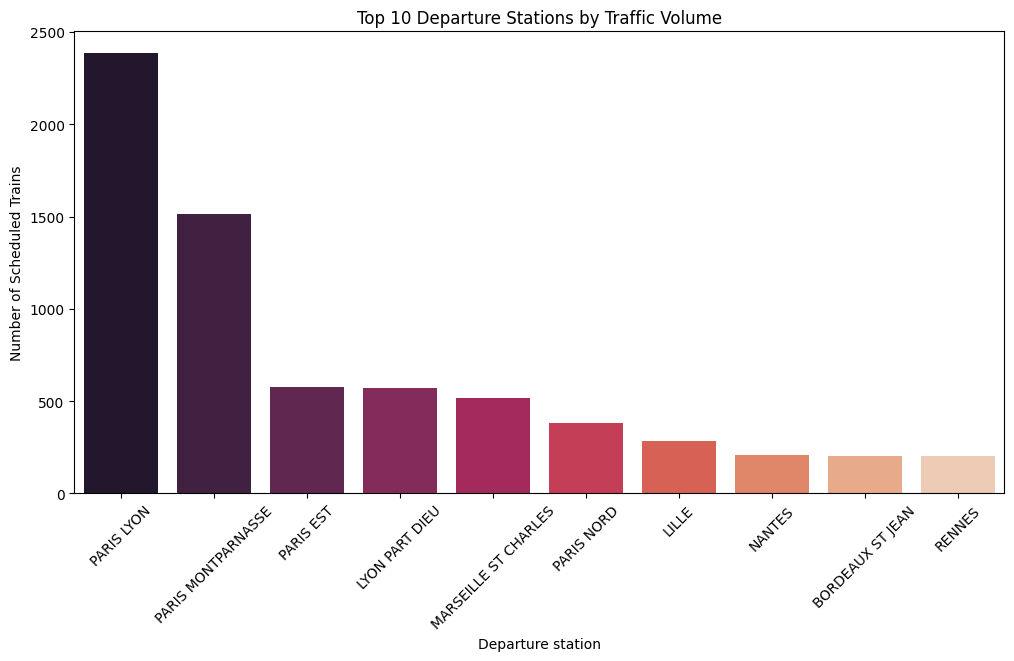

Service               2
Departure station    64
Arrival station      63
Season                4
dtype: int64

Final count after station validation: 11720


In [10]:
for col in ['Departure station', 'Arrival station']:
    # Standardize to uppercase and strip spaces
    df[col] = df[col].str.upper().str.strip()
    
    # Replace null values with Pandas NA
    df[col] = df[col].replace(['NAN', 'NULL'], pd.NA)
    
    # Remove rows where station name is missing
    df = drop_invalid_rows(df, col)

# Visualize Top 10 most frequent Departure Stations
plt.figure(figsize=(12, 6))
top_stations = df['Departure station'].value_counts().nlargest(10)
sns.barplot(x=top_stations.index, y=top_stations.values, hue=top_stations.index, palette='rocket', legend=False)
plt.title('Top 10 Departure Stations by Traffic Volume')
plt.xticks(rotation=45)
plt.ylabel('Number of Scheduled Trains')
plt.show()

print(df[['Service', 'Departure station', 'Arrival station', 'Season']].nunique())
print(f"\nFinal count after station validation: {len(df)}")

### Column Cleanup
We remove columns that contain no data or are not useful for our analysis to streamline the dataset.

In [11]:
# Drop unused comment columns and any other redundant data
cols_to_drop = ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {len(df.columns)}")

Dropped columns: ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
Remaining columns: 27


### Average Journey Time
We clean the journey time by removing the 'min' text and converting the values to integers. Missing values are kept as `NaN` for now, pending a strategic decision on imputation.

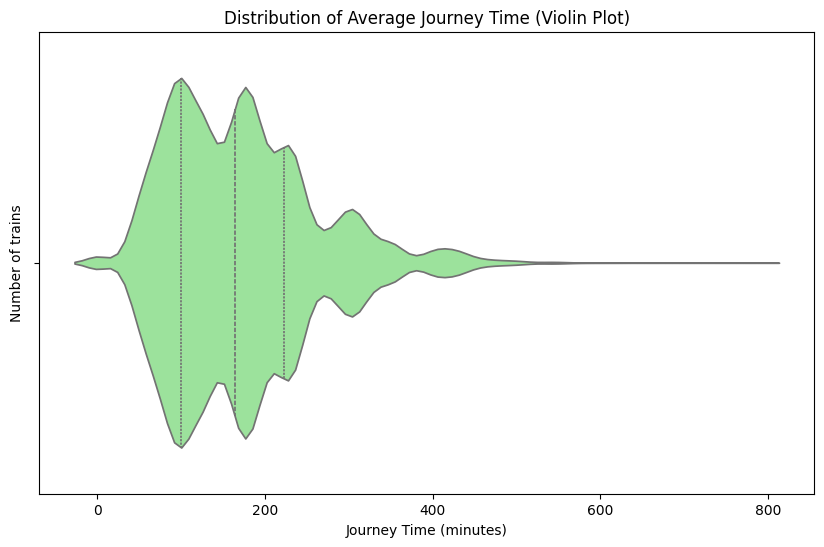

Missing values in Average journey time: 235


In [12]:
# Clean numeric data: remove 'min', handle commas, and convert to Integer
df = clean_numeric_column(df, 'Average journey time', text_to_remove='min', to_type='int')

# TODO: Revisit null values for 'Average journey time'. Currently left as NaN.

# Visualize distribution using a Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['Average journey time'], color='lightgreen', inner='quartile')
plt.title('Distribution of Average Journey Time (Violin Plot)')
plt.xlabel('Journey Time (minutes)')
plt.ylabel('Number of trains')
plt.show()

print(f"Missing values in Average journey time: {df['Average journey time'].isna().sum()}")

### Scheduled and Cancelled Trains
We standardize the number of trains. We also implement a validation rule: the number of cancelled trains cannot exceed the number of scheduled trains.

In [13]:
# Clean Scheduled and Cancelled columns
df = clean_numeric_column(df, 'Number of scheduled trains', to_type='int')
df = clean_numeric_column(df, 'Number of cancelled trains', to_type='int')

# Validation: Cancelled trains cannot exceed Scheduled trains
incoherent_rows = df['Number of cancelled trains'] > df['Number of scheduled trains']
nb_invalid = incoherent_rows.sum()

if nb_invalid > 0:
    print(f"WARNING: {nb_invalid} rows found where cancellations exceed scheduled trains. Setting these cancellation counts to NULL.")
    # TODO: Put Cancelled to NaN
    df.loc[incoherent_rows, 'Number of cancelled trains'] = pd.NA

print(f"Missing 'Scheduled': {df['Number of scheduled trains'].isna().sum()}")
print(f"Missing 'Cancelled': {df['Number of cancelled trains'].isna().sum()}")

Missing 'Scheduled': 234
Missing 'Cancelled': 291


### Departure Delays
We clean the columns related to delays at the departure station. We apply business logic validation:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

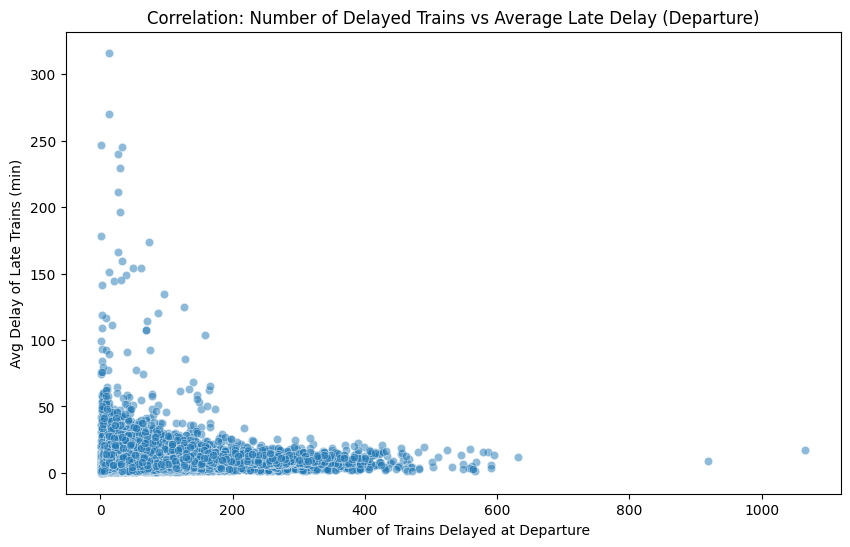

Missing values check:
Number of trains delayed at departure        250
Average delay of late trains at departure    370
Average delay of all trains at departure     233
dtype: int64


In [14]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at departure', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at departure', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at departure', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places for clarity
df['Average delay of late trains at departure'] = df['Average delay of late trains at departure'].round(2)
df['Average delay of all trains at departure'] = df['Average delay of all trains at departure'].round(2)

# Validation 1: Delayed trains vs Scheduled trains
incoherent_rows = df['Number of trains delayed at departure'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed trains exceed scheduled trains. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at departure'] = pd.NA

# Validation 2: If no trains delayed, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at departure'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at departure'] = np.nan

# TODO: Put to NaN

# Visualize correlation between number of delayed trains and average delay
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at departure', y='Average delay of late trains at departure', alpha=0.5)
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Departure)')
plt.xlabel('Number of Trains Delayed at Departure')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check:")
print(df[['Number of trains delayed at departure', 'Average delay of late trains at departure', 'Average delay of all trains at departure']].isna().sum())

### Arrival Delays
We clean the columns related to delays at the arrival station. Similar to departure delays, we apply validation rules:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

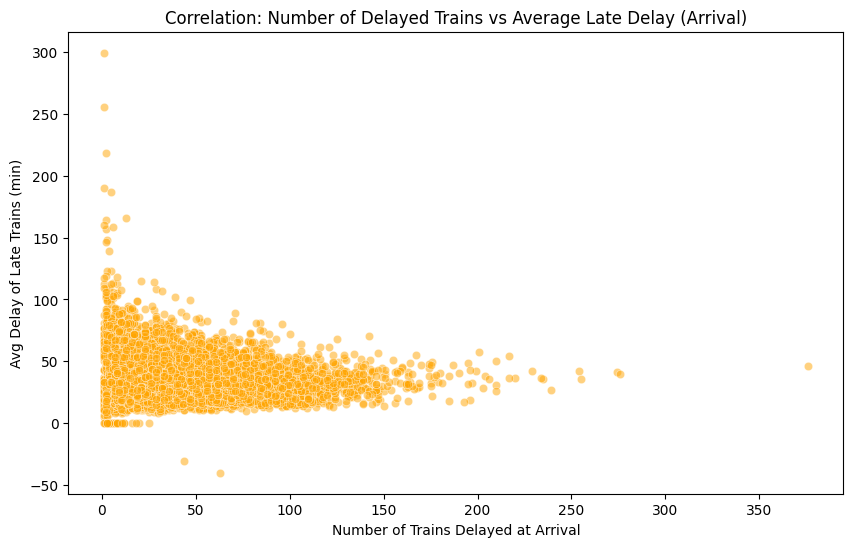

Missing values check (Arrival):
Number of trains delayed at arrival        233
Average delay of late trains at arrival    427
Average delay of all trains at arrival     233
dtype: int64


In [15]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at arrival', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at arrival', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at arrival', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places
df['Average delay of late trains at arrival'] = df['Average delay of late trains at arrival'].round(2)
df['Average delay of all trains at arrival'] = df['Average delay of all trains at arrival'].round(2)

# Validation 1: Delayed trains vs Scheduled trains
incoherent_rows = df['Number of trains delayed at arrival'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed arrival trains exceed scheduled. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at arrival'] = pd.NA

# Validation 2: If no trains delayed at arrival, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at arrival'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at arrival'] = np.nan

# TODO: Revisit remaining null values in arrival delay columns.

# Visualize correlation between number of delayed trains and average delay at arrival
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at arrival', y='Average delay of late trains at arrival', alpha=0.5, color='orange')
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Arrival)')
plt.xlabel('Number of Trains Delayed at Arrival')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check (Arrival):")
print(df[['Number of trains delayed at arrival', 'Average delay of late trains at arrival', 'Average delay of all trains at arrival']].isna().sum())

### Delay and Severity
We clean the columns that categorize delays (>15min, >30min, >60min). 
We also include the average delay for routes competing with flights.

**Validation Rules:**
A logical 'cascade' must be maintained: Total Delayed Arrival >= Delayed > 15min >= Delayed > 30min >= Delayed > 60min.

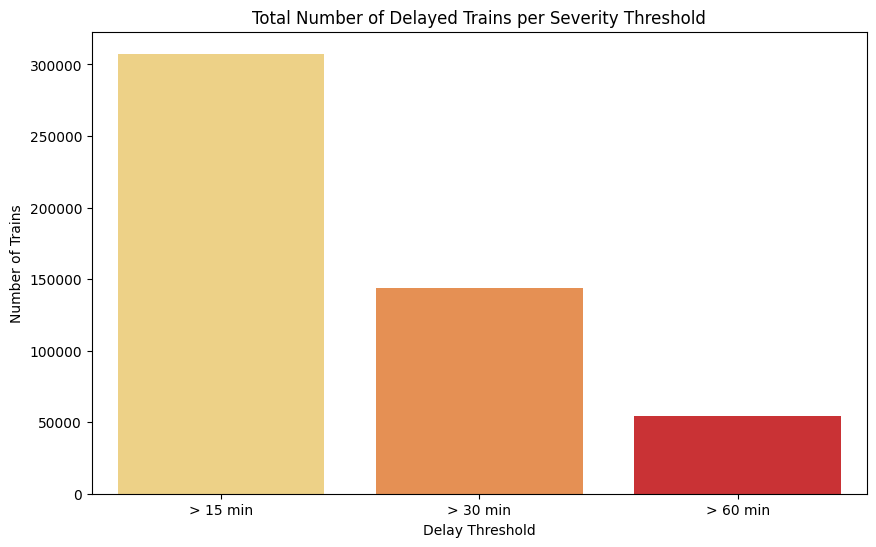

Missing values summary for delay thresholds:
Number of trains delayed > 15min                               264
Number of trains delayed > 30min                               236
Number of trains delayed > 60min                               576
Average delay of trains > 15min (if competing with flights)    232
dtype: int64


In [16]:
# Clean categorized delay counts as Integers
df = clean_numeric_column(df, 'Number of trains delayed > 15min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 30min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 60min', to_type='int')

# Clean flight competition average as Float
df = clean_numeric_column(df, 'Average delay of trains > 15min (if competing with flights)', text_to_remove='min', to_type='float')
df['Average delay of trains > 15min (if competing with flights)'] = df['Average delay of trains > 15min (if competing with flights)'].round(2)

# Validation: Cascade Logic (>15 >= >30 >= >60)
incoherent_rows_15_30 = df['Number of trains delayed > 15min'] < df['Number of trains delayed > 30min']
incoherent_rows_30_60 = df['Number of trains delayed > 30min'] < df['Number of trains delayed > 60min']
incoherent_rows_total_15 = df['Number of trains delayed at arrival'] < df['Number of trains delayed > 15min']

if incoherent_rows_15_30.any() or incoherent_rows_30_60.any() or incoherent_rows_total_15.any():
    total_errors = (incoherent_rows_15_30 | incoherent_rows_30_60 | incoherent_rows_total_15).sum()
    print(f"WARNING: {total_errors} rows found with inconsistent delay cascades. Setting invalid counts to NULL.")
    # Set inconsistent values to NULL to avoid biased statistics
    df.loc[incoherent_rows_15_30, 'Number of trains delayed > 30min'] = pd.NA
    df.loc[incoherent_rows_30_60, 'Number of trains delayed > 60min'] = pd.NA
    df.loc[incoherent_rows_total_15, 'Number of trains delayed > 15min'] = pd.NA

# TODO: Put the three to NaN

# Visualize delay severity levels
delay_sums = df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min']].sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_sums.index, y=delay_sums.values, hue=delay_sums.index, palette='YlOrRd', legend=False)
plt.title('Total Number of Delayed Trains per Severity Threshold')
plt.xlabel('Delay Threshold')
plt.ylabel('Number of Trains')
plt.xticks(ticks=[0, 1, 2], labels=['> 15 min', '> 30 min', '> 60 min'])
plt.show()

print("Missing values summary for delay thresholds:")
print(df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min', 'Average delay of trains > 15min (if competing with flights)']].isna().sum())

### Pct delay due to external causes

Correct the format of the Pct delay due to external causes

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)

In [17]:
values = df["Pct delay due to external causes"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

237 cells has been modified.


2. Clean the number and remove every "%"

In [18]:
values = df["Pct delay due to external causes"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

60 cells has been modified.


3. Convert column to float, because we have percentages here and round to .2 after ,

In [19]:
df["Pct delay due to external causes"] = pd.to_numeric(df["Pct delay due to external causes"].str.replace(",", "."), downcast='float')
df["Pct delay due to external causes"] = df["Pct delay due to external causes"].round(2)

### Pct delay due to infrastructure

Correct the format of the pct delay due to infrastructure

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)

In [20]:
values = df["Pct delay due to infrastructure"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

230 cells has been modified.


2. Clean the number and remove every "%"

In [21]:
values = df["Pct delay due to infrastructure"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

40 cells has been modified.


3. Convert column to float because it's percentages and round to 2 after comma

In [22]:
df["Pct delay due to infrastructure"] = pd.to_numeric(df["Pct delay due to infrastructure"].str.replace(",", "."), downcast='float')
df["Pct delay due to infrastructure"] = df["Pct delay due to infrastructure"].round(2)

### Pct delay due to traffic management

Correct the format of the pct delay due to traffic management

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)

In [23]:
values = df["Pct delay due to traffic management"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

235 cells has been modified.


2. Clean the number and remove all "%"

In [24]:
values = df["Pct delay due to traffic management"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

50 cells has been modified.


3. Convert all column to float because we have percentages and round to 2 after comma

In [25]:
df["Pct delay due to traffic management"] = pd.to_numeric(df["Pct delay due to traffic management"].str.replace(",", "."), downcast='float')
df["Pct delay due to traffic management"] = df["Pct delay due to traffic management"].round(2)

### Pct delay due to rolling stock

Correct the format of the pct delay due to rolling stock

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)

In [26]:
values = df["Pct delay due to rolling stock"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

234 cells has been modified.


2. Clean the number and remove all "%"

In [27]:
values = df["Pct delay due to rolling stock"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

53 cells has been modified.


3. Convert column to float because we have percentages and round of 2 after comma

In [28]:
df["Pct delay due to rolling stock"] = pd.to_numeric(df["Pct delay due to rolling stock"].str.replace(",", "."), downcast='float')
df["Pct delay due to rolling stock"] = df["Pct delay due to rolling stock"].round(2)

### Pct delay due to station management and equipment reuse

Correct the format of the pct delay due to station management and equipment reuse

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)


In [29]:
values = df["Pct delay due to station management and equipment reuse"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

236 cells has been modified.


2. Clean the number and remove "%"

In [30]:
values = df["Pct delay due to station management and equipment reuse"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

67 cells has been modified.


3. Convert column because we have percentages and round of 2 after the comma

In [31]:
df["Pct delay due to station management and equipment reuse"] = pd.to_numeric(df["Pct delay due to station management and equipment reuse"].str.replace(",", "."), downcast='float')
df["Pct delay due to station management and equipment reuse"] = df["Pct delay due to station management and equipment reuse"].round(2)

### Pct delay due to passenger handling (crowding, disabled persons, connections)

Correct the format of the pct delay due to passenger handling (crowding, disabled persons, connections)

1. Replace empty cells with -1 (-1 = No data, and will not be used for statistics)

In [32]:
values = df["Pct delay due to passenger handling (crowding, disabled persons, connections)"]
nb_modified = 0

for i in range(len(values)):
    if pd.isnull(values.iloc[i]):
        values.iloc[i] = "-1"
        nb_modified += 1

df.update(values)
print(f"{nb_modified} cells has been modified.")

233 cells has been modified.


2. Clean the number and remove the "%"

In [33]:
values = df["Pct delay due to passenger handling (crowding, disabled persons, connections)"]
nb_modified = 0

for i in range(len(values)):
    if values.iloc[i].find("%") != -1:
        values.iloc[i] = values.iloc[i].replace("%", "")
        nb_modified += 1
    values.iloc[i] = values.iloc[i].strip()

df.update(values)
print(f"{nb_modified} cells has been modified.")

60 cells has been modified.


3. Convert column to float because we have percentages and round of 2 after the comma

In [34]:
df["Pct delay due to passenger handling (crowding, disabled persons, connections)"] = pd.to_numeric(df["Pct delay due to passenger handling (crowding, disabled persons, connections)"].str.replace(",", "."), downcast='float')
df["Pct delay due to passenger handling (crowding, disabled persons, connections)"] = df["Pct delay due to passenger handling (crowding, disabled persons, connections)"].round(2)

## Dataset after cleaning

In [35]:
print("Column names and new types are: ")

#We get names of columns in the Dataframe
columns = df.columns
for i in range(len(columns)):
    print(columns[i], end=" -> ")
    print(df[str(columns[i])].dtype)

nb_line, nb_col = df.shape

print(f"\nThere is {nb_col} columns and {nb_line} line in the new dataset.\n- {nb_line_start - nb_line} lines has been removed\n- {nb_col_start - nb_col} columns has been removed.\n {((nb_line_start - nb_line) / nb_line_start * 100):.2f}% of the dataset lines were removed")

display(df)

Column names and new types are: 
Year -> 

AttributeError: 'DataFrame' object has no attribute 'dtype'

Exporting the dataset cleaned

In [ ]:
df.to_csv("cleaned_dataset.csv", sep=";", index=False)